In [1]:
import os
from huggingface_hub import login
from dotenv import load_dotenv
load_dotenv()

os.environ["HF_TOKEN"] = os.getenv("HF_WRITE_TOKEN", "")
login(token=os.environ["HF_TOKEN"])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [2]:
from datasets import load_dataset

dataset = load_dataset("emotion")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [3]:
print(dataset["train"][0])       # first row
print(dataset["train"].features) # column types
print(len(dataset["train"]))     # total rows

{'text': 'i didnt feel humiliated', 'label': 0}
{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}
16000


In [4]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

sns.set_theme(style="whitegrid")
dataset = load_dataset("emotion")

In [5]:
print(dataset["train"][0])
print(dataset["train"].features)
print(len(dataset["train"]))

{'text': 'i didnt feel humiliated', 'label': 0}
{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}
16000


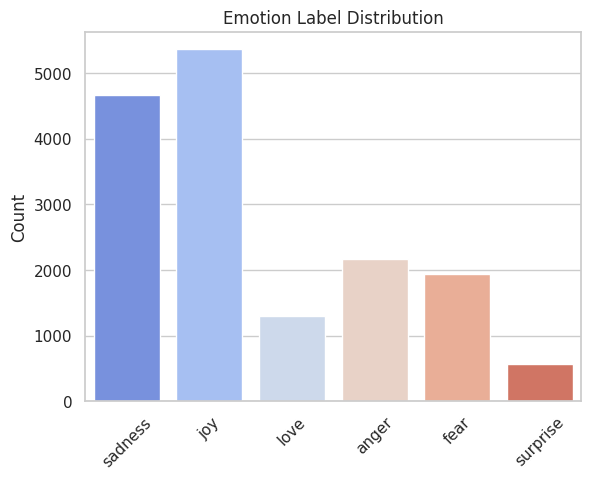

In [6]:
names = ["sadness", "joy", "love", "anger", "fear", "surprise"]
labels = [ex["label"] for ex in dataset["train"]] #type: ignore
counts = [Counter(labels)[i] for i in range(6)]

sns.barplot(x=names, y=counts, hue=names, palette="coolwarm", legend=False)
plt.title("Emotion Label Distribution")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

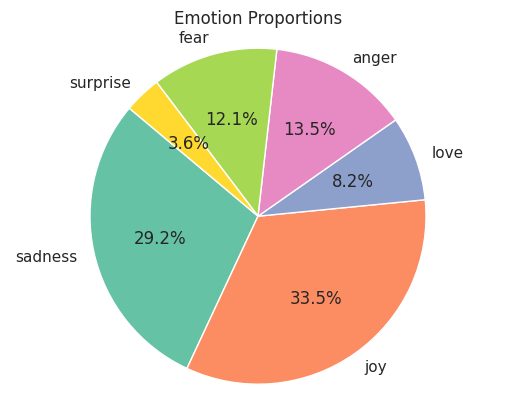

In [7]:
colors = sns.color_palette("Set2", 6)
plt.pie(counts, labels=names, autopct="%1.1f%%", colors=colors, startangle=140)
plt.title("Emotion Proportions")
plt.axis("equal")
plt.show()

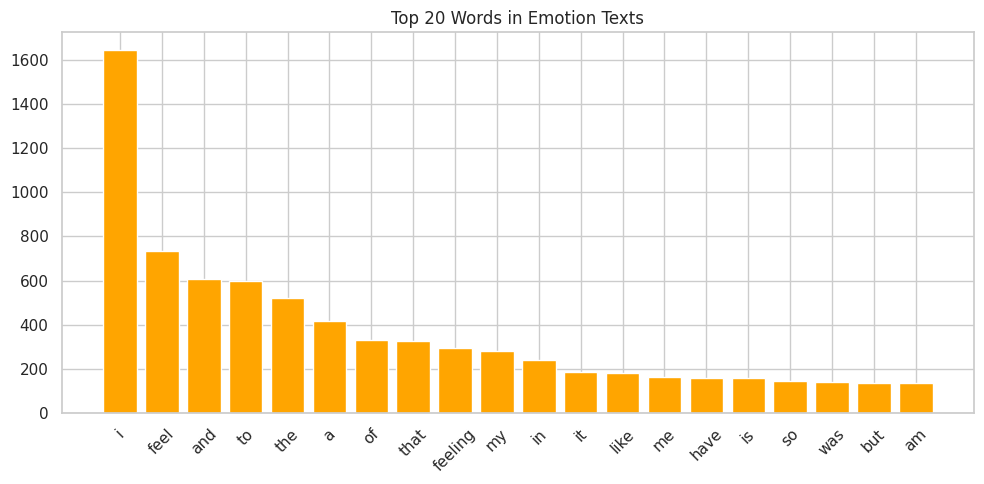

In [10]:
import re

all_words = []
for i in range(1000):
    words = re.findall(r"\w+", dataset["train"][i]["text"].lower())
    all_words.extend(words)

top_words = Counter(all_words).most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 5))
plt.bar(words, counts, color="orange")
plt.xticks(rotation=45)
plt.title("Top 20 Words in Emotion Texts")
plt.tight_layout()
plt.show()

In [11]:
from wordcloud import WordCloud

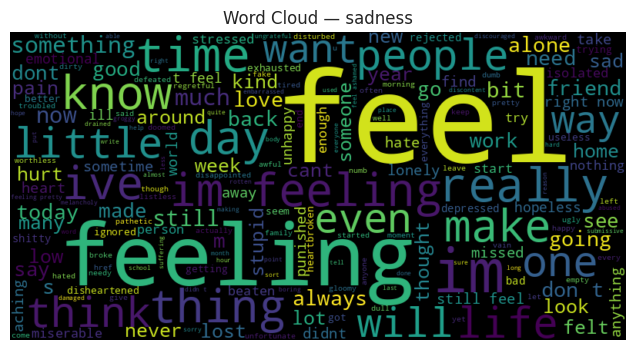

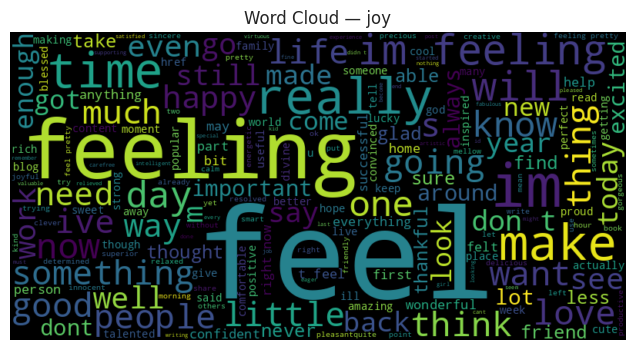

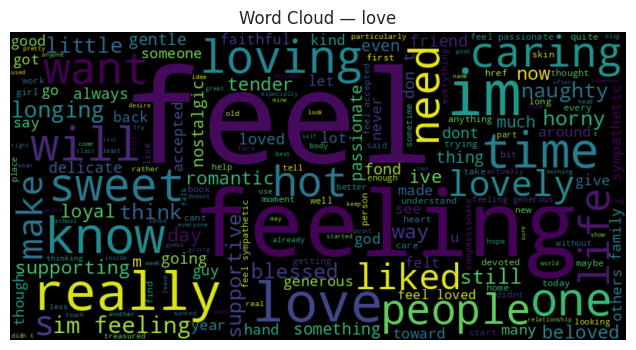

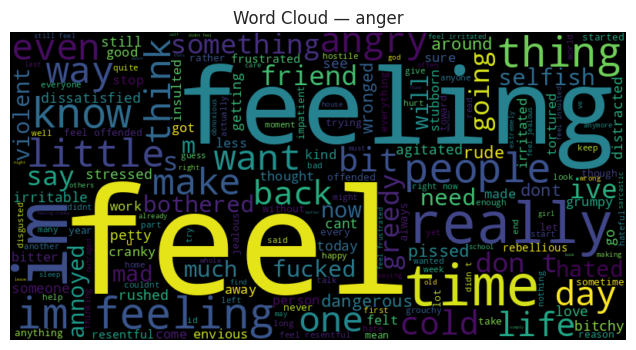

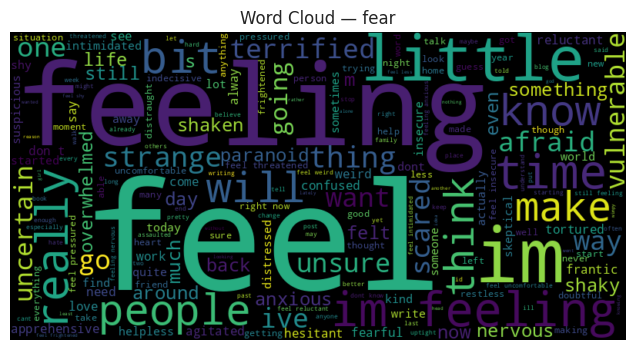

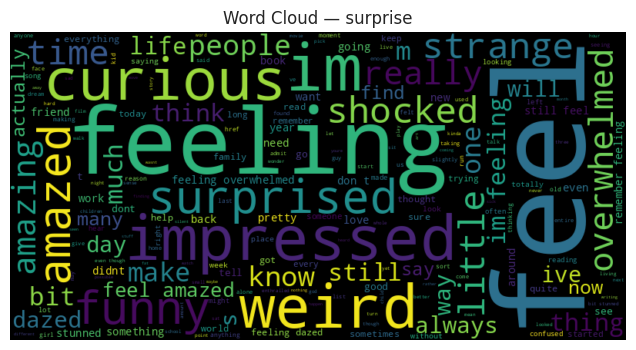

In [12]:
names = ["sadness", "joy", "love", "anger", "fear", "surprise"]

for label_id, label_name in enumerate(names):
    text = " ".join(ex["text"] for ex in dataset["train"] if ex["label"] == label_id) #type: ignore
    wc = WordCloud(width=800, height=400).generate(text)

    plt.figure(figsize=(10, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud — {label_name}")
    plt.show()